# tremordb Stage 1 · 数据预处理（多条件纵向版）

数据集: **Effect of Deep Brain Stimulation on Parkinsonian Tremor** (PhysioNet tremordb v1.0.0)

**v2 核心改动**:
- 条件从 4 个扩展到 **8 个**（加入 washout 时间维度）
- y 列: `[condition_idx, group_idx, subject_num_int]`
- HAT（高幅震颤，1-8号）和 LAT（低幅震颤，9-16号）分别标注
- 包含 washout 时间序列：DBS 关闭后 t=0/15/30/45/60 分钟

**8个条件定义**:
```
0: DBS-ON  + Med-ON   (ren)        HAT效应最弱，充分治疗
1: DBS-ON  + Med-OFF  (ref)        单纯DBS效果
2: DBS-OFF + Med-ON   (ron)        单纯药物效果
3: DBS-OFF + Med-OFF  (rof, t=0)   基线，无治疗
4: DBS-OFF + Med-OFF, t=15min (r15of)  ← 纵向轨迹开始
5: DBS-OFF + Med-OFF, t=30min (r30of)
6: DBS-OFF + Med-OFF, t=45min (r45of)
7: DBS-OFF + Med-OFF, t=60min (r60of)  ← 震颤完全恢复
```

**Group 定义**:
- HAT (group=0): subjects 1-8，高幅震颤，DBS主要治疗震颤
- LAT (group=1): subjects 9-16，低幅震颤，DBS主要治疗强直/运动障碍

**Outputs**: `tremor_X_{train,val,test}.npy`, `tremor_y_{train,val,test}.npy`, `label_dict.json`

In [1]:
!pip install wfdb -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os, re, json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_DIR = Path('./tremordb')
DATA_DIR.mkdir(exist_ok=True)
print('Working dir:', Path('.').resolve())

Working dir: /Users/echozhang/Desktop/CVAE


## 1. 下载数据集（~3.5 MB）

In [2]:
import urllib.request
from urllib.parse import urljoin

BASE_URL = 'https://physionet.org/files/tremordb/1.0.0/'

def fetch_html(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return resp.read().decode('utf-8', errors='ignore')

def list_files_recursive(url):
    try:
        html = fetch_html(url)
    except Exception as e:
        print(f'  error {url}: {e}'); return []
    out = []
    for href in re.findall(r'href="([^"]+)"', html):
        if href.startswith(('?','#','/','http://','https://')) or href=='../':
            continue
        full_url = urljoin(url, href)
        if not full_url.startswith(BASE_URL): continue
        if href.endswith('/'):
            out.extend(list_files_recursive(full_url))
        elif re.search(r'\.(let|rit|hea|dat)$', href, re.IGNORECASE):
            out.append(full_url)
    return out

if not list(DATA_DIR.rglob('*.let')):
    all_urls = list_files_recursive(BASE_URL)
    print(f'{len(all_urls)} files found, downloading...')
    fail = []
    for url in all_urls:
        rel = url[len(BASE_URL):]
        out = DATA_DIR / rel
        out.parent.mkdir(parents=True, exist_ok=True)
        if out.exists() and out.stat().st_size > 0: continue
        try: urllib.request.urlretrieve(url, out)
        except Exception as e: fail.append((rel, str(e)))
    print(f'Done (failures: {len(fail)})')
else:
    print('Dataset already downloaded.')

all_files = sorted(list(DATA_DIR.rglob('*.let')) + list(DATA_DIR.rglob('*.rit')))
print(f'Signal files: {len(all_files)}')

117 files found, downloading...
Done (failures: 0)
Signal files: 101


## 2. 文件名解析 + 条件编码

**8 条件编码（含 washout 时间维度）**:
- 0: DBS-ON  Med-ON   (ren)
- 1: DBS-ON  Med-OFF  (ref)
- 2: DBS-OFF Med-ON   (ron)
- 3: DBS-OFF Med-OFF  t=0  (rof, steady)
- 4: DBS-OFF Med-OFF  t=15 (r15of)
- 5: DBS-OFF Med-OFF  t=30 (r30of)
- 6: DBS-OFF Med-OFF  t=45 (r45of)
- 7: DBS-OFF Med-OFF  t=60 (r60of)

In [3]:
FILENAME_RE = re.compile(r'^(?P<target>[vsg])(?P<subj>\d{1,2})r(?P<dbs>e|o|\d+o)(?P<med>[nf])$')
TARGET_MAP  = {'v': 'Vim', 's': 'STN', 'g': 'GPi'}

# ── 8 条件映射 ──────────────────────────────────────────────────────────
COND_MAP = {
    ('ON',  'ON',  None): 0,   # DBS-ON  Med-ON
    ('ON',  'OFF', None): 1,   # DBS-ON  Med-OFF
    ('OFF', 'ON',  None): 2,   # DBS-OFF Med-ON
    ('OFF', 'OFF', None): 3,   # DBS-OFF Med-OFF steady
    ('OFF', 'OFF', 15):   4,   # DBS-OFF t=15min
    ('OFF', 'OFF', 30):   5,   # DBS-OFF t=30min
    ('OFF', 'OFF', 45):   6,   # DBS-OFF t=45min
    ('OFF', 'OFF', 60):   7,   # DBS-OFF t=60min
}
COND_INV = {v: k for k, v in COND_MAP.items()}
COND_NAMES = {
    0: 'DBS-ON/Med-ON',
    1: 'DBS-ON/Med-OFF',
    2: 'DBS-OFF/Med-ON',
    3: 'DBS-OFF/Med-OFF (t=0)',
    4: 'DBS-OFF/Med-OFF (t=15)',
    5: 'DBS-OFF/Med-OFF (t=30)',
    6: 'DBS-OFF/Med-OFF (t=45)',
    7: 'DBS-OFF/Med-OFF (t=60)',
}
GROUP_MAP  = {True: 0, False: 1}  # HAT=0, LAT=1


def parse_filename(filepath):
    p   = Path(filepath)
    m   = FILENAME_RE.match(p.stem.lower())
    if m is None: return None
    subj_num = int(m.group('subj'))
    if not 1 <= subj_num <= 16: return None
    dbs_raw = m.group('dbs')
    if dbs_raw == 'e':
        dbs_state, dbs_off_min = 'ON', None
    elif dbs_raw == 'o':
        dbs_state, dbs_off_min = 'OFF', None
    else:
        dbs_state, dbs_off_min = 'OFF', int(dbs_raw[:-1])
    med = 'ON' if m.group('med') == 'n' else 'OFF'
    is_hat = (subj_num <= 8)
    cond_key = (dbs_state, med, dbs_off_min)
    cond_idx  = COND_MAP.get(cond_key, -1)
    group_idx = 0 if is_hat else 1
    return {
        'filepath':    str(filepath),
        'target':      TARGET_MAP[m.group('target')],
        'subject_num': subj_num,
        'subject_id':  f"{m.group('target')}{subj_num}",
        'group':       'HAT' if is_hat else 'LAT',
        'group_idx':   group_idx,
        'dbs_state':   dbs_state,
        'dbs_off_min': dbs_off_min,
        'medication':  med,
        'side':        'left' if p.suffix.lower() == '.let' else 'right',
        'cond_idx':    cond_idx,
        'cond_name':   COND_NAMES.get(cond_idx, 'UNKNOWN'),
    }


# .hea 文件解析
def parse_hea(hea_path):
    meta = {}; fs = None; in_table = False
    for line in Path(hea_path).read_text().splitlines():
        if fs is None and not line.startswith('#') and not line.startswith(' '):
            parts = line.split()
            if len(parts) >= 3:
                try: fs = int(parts[2])
                except: pass
        if line.startswith('# SUBJ') and 'FILE' in line:
            in_table = True; continue
        if in_table and line.startswith('#'):
            cols = line.lstrip('#').split()
            if len(cols) >= 7:
                try:
                    meta[cols[1]] = {'range': float(cols[2]),
                                     'samples': int(cols[6]),
                                     'fs': int(cols[5])}
                except: pass
    return meta


ALL_FILE_META = {}
for hea in DATA_DIR.rglob('*.hea'):
    ALL_FILE_META.update(parse_hea(hea))

records, failures = [], []
for f in all_files:
    m = parse_filename(f)
    if m is None: failures.append(f.name); continue
    if m['cond_idx'] == -1: failures.append(f.name); continue  # unknown condition
    h = ALL_FILE_META.get(f.name, {})
    m.update({'fs': h.get('fs'), 'range_ms': h.get('range'), 'samples': h.get('samples')})
    records.append(m)

df_meta = pd.DataFrame(records)
print(f'Parsed: {len(df_meta)}, skipped: {len(failures)}')

print('\n=== 条件 × Group 分布 ===')
print(df_meta.groupby(['cond_name','group']).size().unstack(fill_value=0))

print('\n=== 采样率分布 ===')
print(df_meta['fs'].value_counts(dropna=False).to_dict())

Parsed: 101, skipped: 0

=== 条件 × Group 分布 ===
group                   HAT  LAT
cond_name                       
DBS-OFF/Med-OFF (t=0)     6    8
DBS-OFF/Med-OFF (t=15)    3    8
DBS-OFF/Med-OFF (t=30)    4    8
DBS-OFF/Med-OFF (t=45)    3    8
DBS-OFF/Med-OFF (t=60)    4    8
DBS-OFF/Med-ON            7    8
DBS-ON/Med-OFF            5    8
DBS-ON/Med-ON             5    8

=== 采样率分布 ===
{100.0: 97, nan: 4}


## 3. 信号加载 + 验证

In [4]:
def load_signal(filepath):
    p = Path(filepath)
    try:
        with open(p) as f:
            sig = np.array([float(l.strip()) for l in f if l.strip()], dtype=np.float32)
    except Exception as e:
        print(f'  read error {p.name}: {e}'); return None, None
    if len(sig) == 0: return None, None
    sig = np.nan_to_num(sig, nan=0.0)
    meta = ALL_FILE_META.get(p.name, {})
    fs   = int(meta.get('fs') or 100)
    rng  = meta.get('range')
    if rng is not None and rng > 0:
        sig = sig * float(rng)
    return sig, fs


DUR_MIN_S = 10.0
rows = []
for _, r in df_meta.iterrows():
    sig, fs = load_signal(r['filepath'])
    if sig is None:
        rows.append({**r.to_dict(), 'duration_s': None, 'rms': None, 'ok': False})
        continue
    rows.append({**r.to_dict(),
                 'duration_s': len(sig)/fs,
                 'rms':        float(np.sqrt(np.mean(sig**2))),
                 'ok':         True})

df_diag  = pd.DataFrame(rows)
df_clean = df_diag[df_diag['ok'] & (df_diag['duration_s'] >= DUR_MIN_S)].copy()
print(f'Loaded: {df_diag["ok"].sum()}/{len(df_diag)}')
print(f'Retained (≥{DUR_MIN_S}s): {len(df_clean)}')
print(f'Duration: mean={df_clean["duration_s"].mean():.1f}s  '
      f'range=[{df_clean["duration_s"].min():.1f}, {df_clean["duration_s"].max():.1f}]s')

# HAT subjects: 验证有 DBS-ON 和 DBS-OFF 配对记录的受试者
hat_df = df_clean[df_clean['group']=='HAT']
print('\n=== HAT受试者条件覆盖 ===')
print(hat_df.groupby(['subject_id','cond_name']).size().unstack(fill_value=0))

Loaded: 101/101
Retained (≥10.0s): 101
Duration: mean=67.1s  range=[34.0, 121.1]s

=== HAT受试者条件覆盖 ===
cond_name   DBS-OFF/Med-OFF (t=0)  DBS-OFF/Med-OFF (t=15)  \
subject_id                                                  
g1                              0                       0   
g2                              1                       1   
s6                              1                       1   
s7                              1                       0   
s8                              1                       1   
v4                              1                       0   
v5                              1                       0   

cond_name   DBS-OFF/Med-OFF (t=30)  DBS-OFF/Med-OFF (t=45)  \
subject_id                                                   
g1                               0                       0   
g2                               1                       1   
s6                               1                       1   
s7                               1    

## 4. EDA — HAT vs LAT 震颤对比

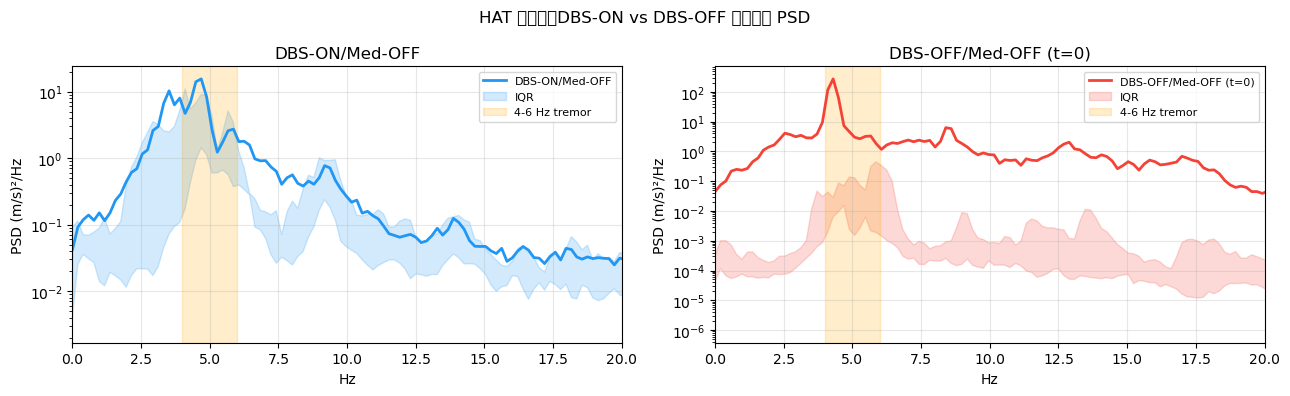

In [5]:
# 展示 HAT 受试者在 DBS-ON vs DBS-OFF 条件下的 PSD 对比
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('HAT 受试者：DBS-ON vs DBS-OFF 震颤速度 PSD')

colors = {0: '#2196F3', 3: '#F44336'}
labels = {0: 'DBS-ON Med-OFF', 3: 'DBS-OFF Med-OFF (t=0)'}

for ax_idx, (cond_idx, color, label) in enumerate([
    (1, '#2196F3', 'DBS-ON/Med-OFF'),
    (3, '#F44336', 'DBS-OFF/Med-OFF (t=0)'),
]):
    rows_c = df_clean[(df_clean['group']=='HAT') & (df_clean['cond_idx']==cond_idx)]
    psds = []
    for _, row in rows_c.iterrows():
        sig, fs = load_signal(row['filepath'])
        if sig is None: continue
        f_arr, p = signal.welch(sig, fs=fs, nperseg=min(512, len(sig)))
        psds.append(p)
    if psds:
        psds = np.array(psds)
        axes[ax_idx].semilogy(f_arr, psds.mean(axis=0), color=color, lw=2, label=label)
        axes[ax_idx].fill_between(f_arr,
                                   np.percentile(psds, 25, axis=0),
                                   np.percentile(psds, 75, axis=0),
                                   color=color, alpha=0.2, label='IQR')
    axes[ax_idx].axvspan(4, 6, color='orange', alpha=0.2, label='4-6 Hz tremor')
    axes[ax_idx].set_xlim(0, 20); axes[ax_idx].set_xlabel('Hz')
    axes[ax_idx].set_ylabel('PSD (m/s)²/Hz')
    axes[ax_idx].set_title(label); axes[ax_idx].legend(fontsize=8); axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hat_dbs_comparison.png', dpi=130)
plt.show()

## 5. 滤波 + 窗口提取

In [6]:
FS_DEFAULT = None   # 从数据自动确定
WINDOW_SEC = 1.2
OVERLAP    = 0.5

def bandpass(sig, fs, low=1.0, high=20.0, order=4):
    from scipy.signal import butter, sosfiltfilt
    sos = butter(order, [low/(fs/2), high/(fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, sig).astype(np.float32)


X_all, y_all = [], []
fs_seen = set()

for _, row in df_clean.iterrows():
    sig, fs = load_signal(row['filepath'])
    if sig is None: continue
    fs_seen.add(fs)
    win_len = int(WINDOW_SEC * fs)
    step    = int(win_len * (1 - OVERLAP))
    sig_f   = bandpass(sig, fs)
    # z-score per recording
    mu, sd = sig_f.mean(), sig_f.std() + 1e-8
    sig_z  = (sig_f - mu) / sd
    s = 0
    while s + win_len <= len(sig_z):
        X_all.append(sig_z[s:s+win_len])
        y_all.append([row['cond_idx'], row['group_idx'], row['subject_num']])
        s += step

X_all = np.stack(X_all).astype(np.float32)
y_all = np.array(y_all, dtype=np.int64)

FS = sorted(fs_seen)[0] if fs_seen else 100
WINDOW_LEN = int(WINDOW_SEC * FS)

print(f'FS observed: {fs_seen}  → using FS={FS}')
print(f'WINDOW_LEN={WINDOW_LEN}  Total windows: {X_all.shape}')
print('\n=== Windows per condition × group ===')
df_y = pd.DataFrame(y_all, columns=['cond_idx','group_idx','subj'])
print(df_y.groupby(['cond_idx','group_idx']).size().unstack(fill_value=0)
      .rename(columns={0:'HAT',1:'LAT'})
      .rename(index=lambda i: COND_NAMES[i]))

FS observed: {100}  → using FS=100
WINDOW_LEN=120  Total windows: (11145, 120)

=== Windows per condition × group ===
group_idx               HAT  LAT
cond_idx                        
DBS-ON/Med-ON           541  847
DBS-ON/Med-OFF          569  849
DBS-OFF/Med-ON          781  988
DBS-OFF/Med-OFF (t=0)   631  853
DBS-OFF/Med-OFF (t=15)  360  841
DBS-OFF/Med-OFF (t=30)  519  853
DBS-OFF/Med-OFF (t=45)  383  847
DBS-OFF/Med-OFF (t=60)  435  848


## 6. Train / Val / Test Split（按受试者）

In [7]:
rng = np.random.RandomState(42)

# 每个 (group) 取 1 个 val、1 个 test 受试者
val_subj, test_subj = [], []
for grp in [0, 1]:  # HAT=0, LAT=1
    subj_list = sorted(set(y_all[y_all[:,1]==grp, 2]))
    if len(subj_list) >= 2:
        chosen = rng.choice(subj_list, size=2, replace=False)
        val_subj.append(int(chosen[0]))
        test_subj.append(int(chosen[1]))

train_mask = ~np.isin(y_all[:,2], val_subj + test_subj)
val_mask   =  np.isin(y_all[:,2], val_subj)
test_mask  =  np.isin(y_all[:,2], test_subj)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')
print(f'\nTrain HAT subjects: {sorted(set(y_train[y_train[:,1]==0,2]))}')
print(f'Train LAT subjects: {sorted(set(y_train[y_train[:,1]==1,2]))}')
print(f'Val  subjects: {val_subj}  |  Test subjects: {test_subj}')

Train (8195, 120)  Val (1153, 120)  Test (1797, 120)

Train HAT subjects: [4, 5, 6, 7, 8]
Train LAT subjects: [10, 11, 12, 13, 15, 16]
Val  subjects: [1, 14]  |  Test subjects: [2, 9]


## 7. 保存 Artifacts

In [8]:
np.save('tremor_X_train.npy', X_train); np.save('tremor_y_train.npy', y_train)
np.save('tremor_X_val.npy',   X_val);   np.save('tremor_y_val.npy',   y_val)
np.save('tremor_X_test.npy',  X_test);  np.save('tremor_y_test.npy',  y_test)

label_dict = {
    'n_conditions':  8,
    'condition_names': COND_NAMES,
    'n_groups':      2,
    'group_names':   {0: 'HAT', 1: 'LAT'},
    'window_sec':    WINDOW_SEC,
    'window_len':    WINDOW_LEN,
    'sampling_rate': FS,
    'overlap':       OVERLAP,
    'y_columns':     ['cond_idx', 'group_idx', 'subject_num'],
    'hat_subjects':  sorted([int(s) for s in df_clean[df_clean.group=='HAT'].subject_num.unique()]),
    'lat_subjects':  sorted([int(s) for s in df_clean[df_clean.group=='LAT'].subject_num.unique()]),
    'val_subjects':  [int(s) for s in val_subj],
    'test_subjects': [int(s) for s in test_subj],
}
with open('label_dict.json', 'w') as f:
    json.dump(label_dict, f, indent=2)

print('Artifacts saved:')
for fname in ['tremor_X_train.npy','tremor_y_train.npy','tremor_X_val.npy',
              'tremor_y_val.npy','tremor_X_test.npy','tremor_y_test.npy','label_dict.json']:
    p = Path(fname)
    if p.exists(): print(f'  {fname:30s} {p.stat().st_size/1e3:.1f} KB')

print('\n=== Summary ===')
print(f'  8 conditions (4 base + 4 washout time points)')
print(f'  HAT subjects (DBS→tremor suppression): {label_dict["hat_subjects"]}')
print(f'  LAT subjects (DBS→rigidity/dyskinesia): {label_dict["lat_subjects"]}')
print('  → Stage 3 power analysis focuses on HAT, paired DBS-ON vs DBS-OFF')

Artifacts saved:
  tremor_X_train.npy             3933.7 KB
  tremor_y_train.npy             196.8 KB
  tremor_X_val.npy               553.6 KB
  tremor_y_val.npy               27.8 KB
  tremor_X_test.npy              862.7 KB
  tremor_y_test.npy              43.3 KB
  label_dict.json                0.8 KB

=== Summary ===
  8 conditions (4 base + 4 washout time points)
  HAT subjects (DBS→tremor suppression): [1, 2, 4, 5, 6, 7, 8]
  LAT subjects (DBS→rigidity/dyskinesia): [9, 10, 11, 12, 13, 14, 15, 16]
  → Stage 3 power analysis focuses on HAT, paired DBS-ON vs DBS-OFF
